In [ ]:
DATA_PATH = "maxtwo_pipeline_results_sttc50_units100_minspikes5/260527__T003708__Network__000039__data/phenotype_matrix.csv"


Loaded: (6532, 85)
Clustered: (6532, 89)

Well summary:
    well_id  n_units  best_k  silhouette
0   well000       36       2    0.923294
1   well001       73       2    0.822781
2   well002       44       2    0.335662
3   well003       56       2    0.812658
4   well004       36       3    0.429535
5   well005       65       2    0.851738
6   well006      126       2    0.834519
7   well007      164       2    0.814528
8   well008      144       2    0.849910
9   well009      138       2    0.830248
10  well010      145       2    0.844351
11  well011      116       2    0.833776
12  well012       91       2    0.563687
13  well013       61       2    0.834180
14  well014       77       2    0.883087
15  well015       78       2    0.869855
16  well016       85       2    0.822210
17  well017       89       4    0.384985
18  well018     1020       2    0.840453
19  well019      992       2    0.808090
20  well020      889       2    0.837191
21  well021      836       2    0.827022
2

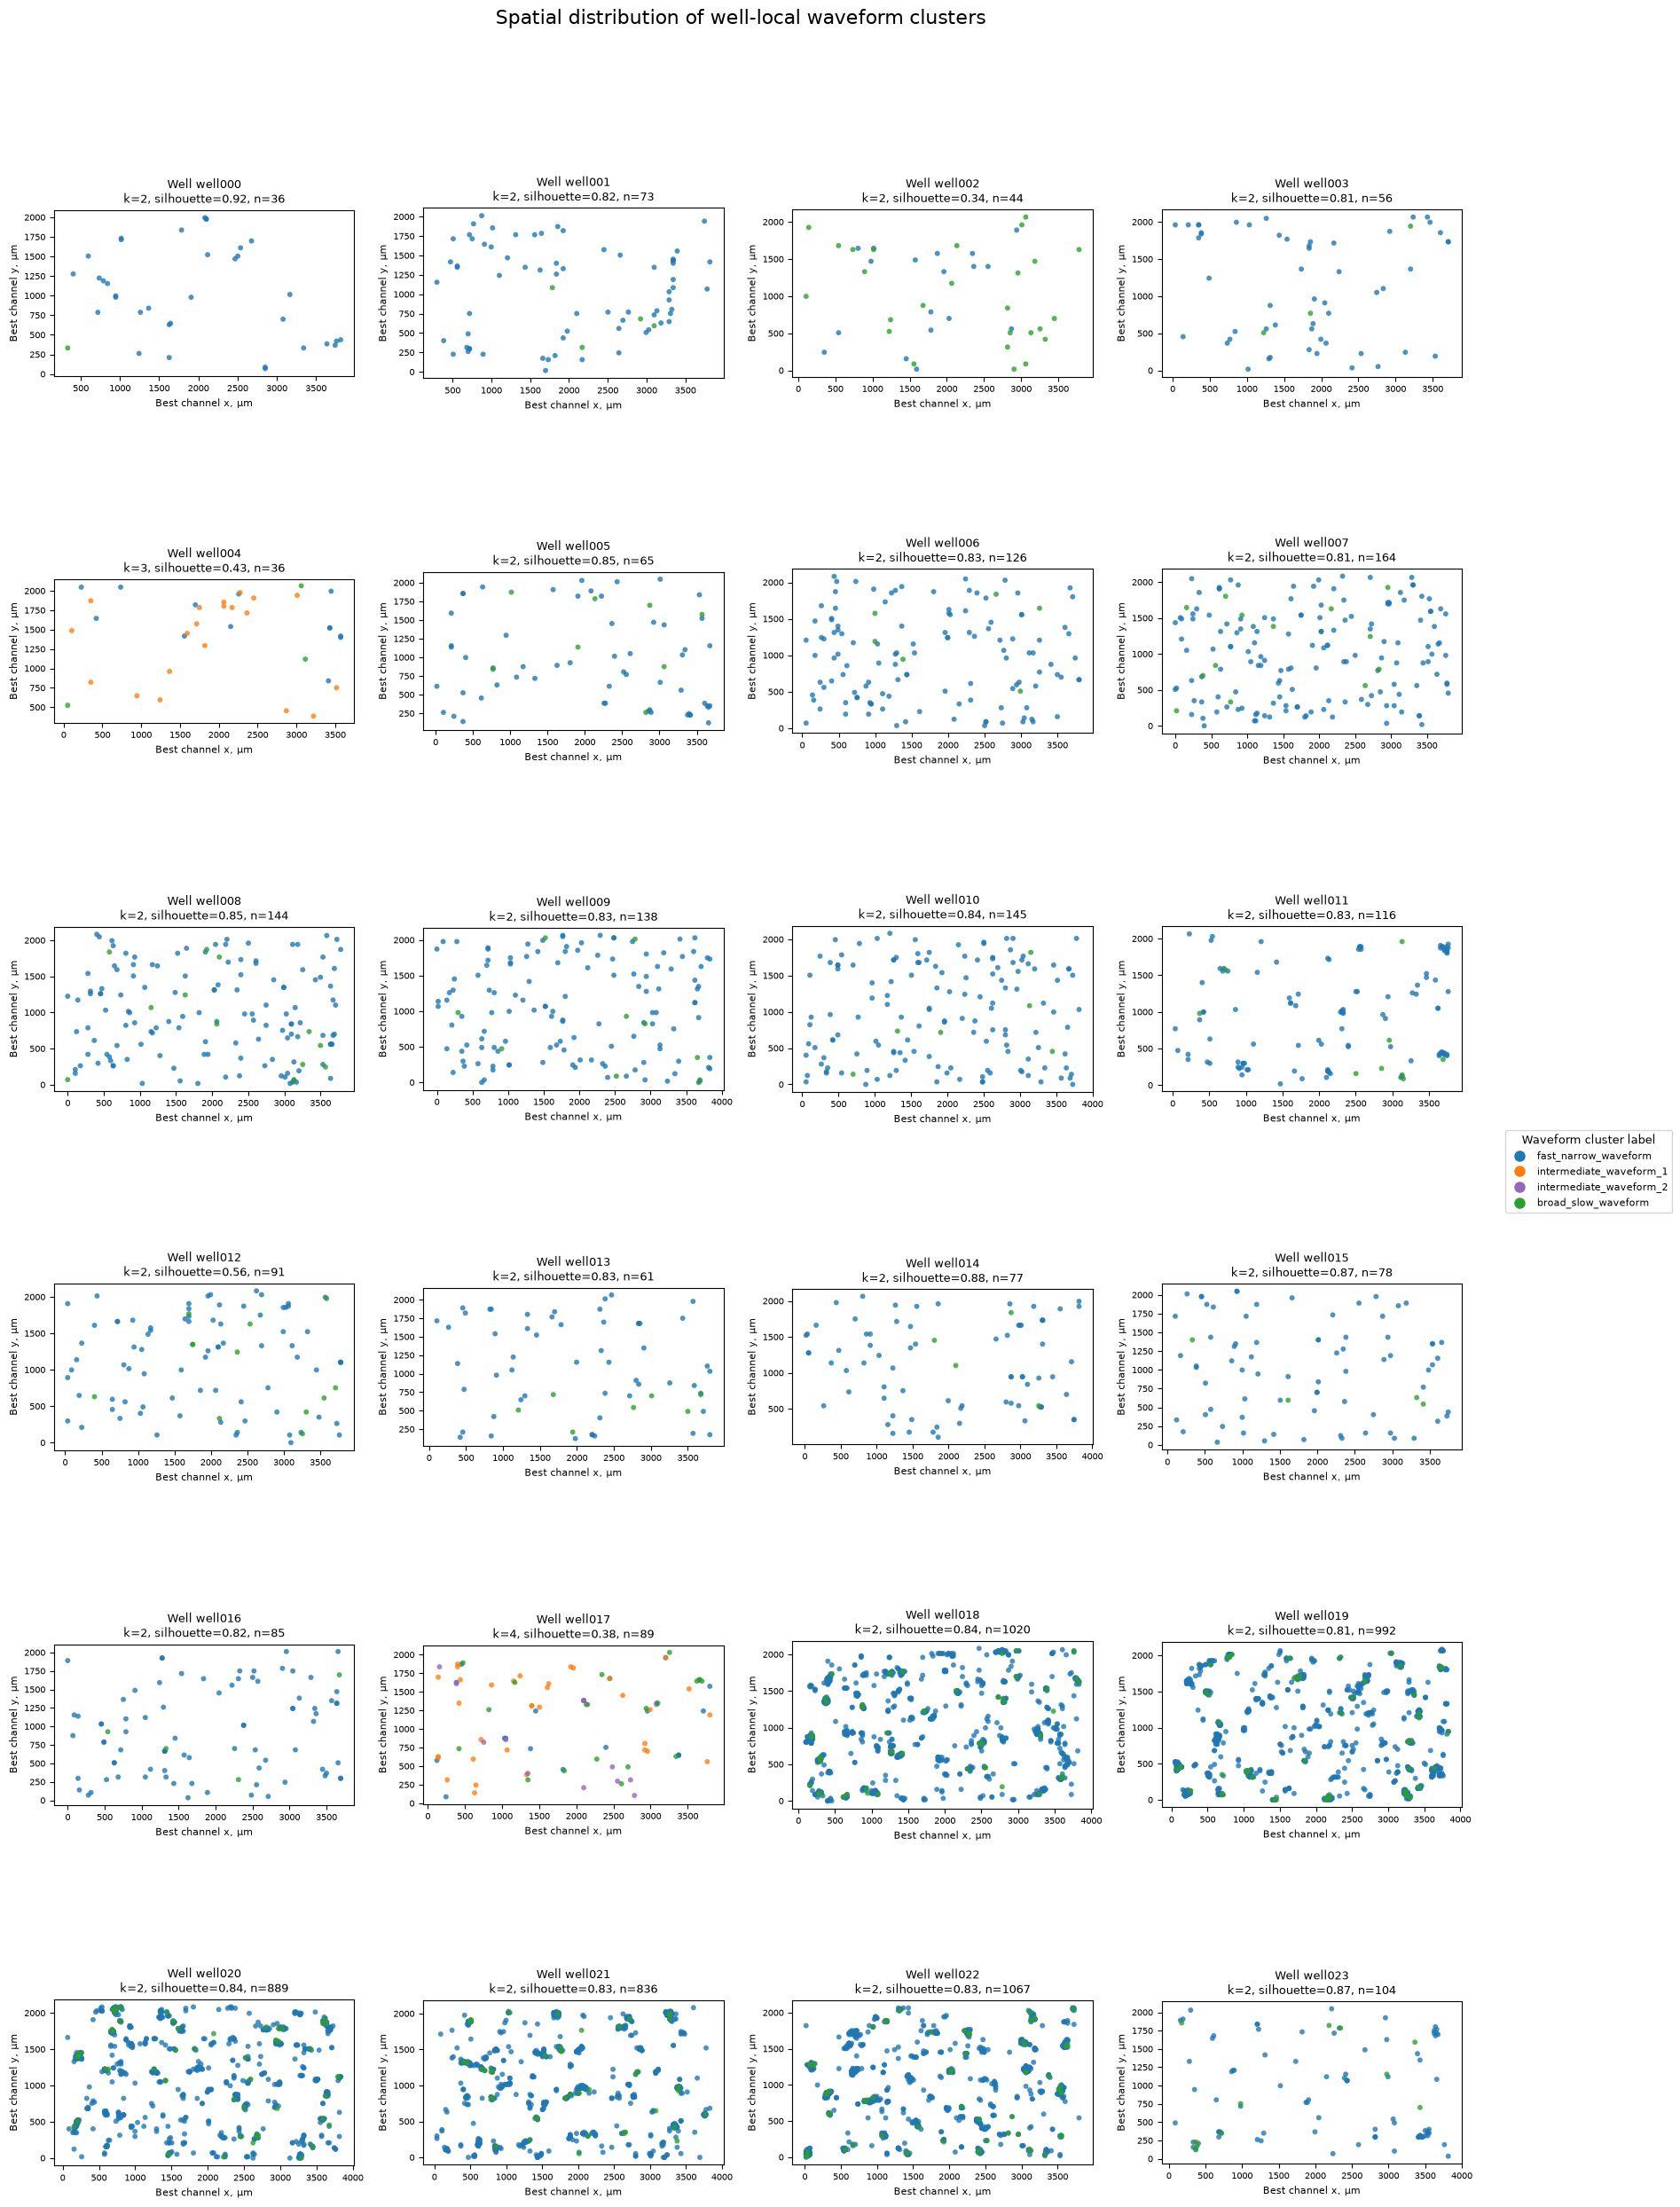


Saved:
spatial_waveform_clusters_per_well.png
phenotype_matrix_waveform_clustered_per_well.csv
waveform_cluster_summary_per_well.csv
waveform_clustering_well_summary.csv
waveform_cluster_counts_per_well.csv


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ============================================================
# 1. Load data
# ============================================================
DATA_PATH = (
    "maxtwo_pipeline_results_sttc50_units100_minspikes5/"
    "260527__T003708__Network__000039__data/"
    "phenotype_matrix.csv"
)

df = pd.read_csv(DATA_PATH)

print("Loaded:", df.shape)


# ============================================================
# 2. Define features
# ============================================================
raw_waveform_cols = [
    "template_p2p_max_uV",
    "template_trough_to_peak_ms",
    "template_half_width_ms",
    "template_repolarization_slope_uV_per_ms",
]

spatial_cols = [
    "template_best_channel_x_um",
    "template_best_channel_y_um",
]

required_cols = ["well_id"] + raw_waveform_cols + spatial_cols
missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")


# ============================================================
# 3. Remove old clustering columns if re-running
# ============================================================
old_cols = [
    "well_waveform_cluster",
    "well_waveform_cluster_label",
    "well_waveform_best_k",
    "well_waveform_silhouette",
]

df = df.drop(columns=[c for c in old_cols if c in df.columns], errors="ignore")


# ============================================================
# 4. Cluster one well
# ============================================================
def cluster_waveforms_in_well(
    well_df,
    min_units_for_clustering=10,
    k_min=2,
    k_max=4,
    random_state=42,
):
    well_df = well_df.copy()
    n_units = len(well_df)

    if n_units < min_units_for_clustering:
        well_df["well_waveform_cluster"] = -1
        well_df["well_waveform_cluster_label"] = "too_few_units"
        well_df["well_waveform_best_k"] = 0
        well_df["well_waveform_silhouette"] = np.nan
        return well_df

    # -----------------------------
    # Feature matrix
    # -----------------------------
    wave = well_df[raw_waveform_cols].copy()

    # Log-transform amplitude to reduce domination by amplitude scale
    wave["log_template_p2p_max_uV"] = np.log1p(
        wave["template_p2p_max_uV"].clip(lower=0)
    )

    cluster_features = [
        "log_template_p2p_max_uV",
        "template_trough_to_peak_ms",
        "template_half_width_ms",
        "template_repolarization_slope_uV_per_ms",
    ]

    X_raw = wave[cluster_features].replace([np.inf, -np.inf], np.nan)

    preprocess = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]
    )

    X = preprocess.fit_transform(X_raw)

    possible_k = list(range(k_min, min(k_max, n_units - 1) + 1))

    if len(possible_k) == 0:
        well_df["well_waveform_cluster"] = -1
        well_df["well_waveform_cluster_label"] = "too_few_units"
        well_df["well_waveform_best_k"] = 0
        well_df["well_waveform_silhouette"] = np.nan
        return well_df

    # -----------------------------
    # Pick k by silhouette score
    # -----------------------------
    silhouette_scores = {}

    for k in possible_k:
        model = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=50,
        )

        labels = model.fit_predict(X)

        if len(np.unique(labels)) > 1:
            silhouette_scores[k] = silhouette_score(X, labels)

    if len(silhouette_scores) == 0:
        well_df["well_waveform_cluster"] = -1
        well_df["well_waveform_cluster_label"] = "clustering_failed"
        well_df["well_waveform_best_k"] = 0
        well_df["well_waveform_silhouette"] = np.nan
        return well_df

    best_k = max(silhouette_scores, key=silhouette_scores.get)
    best_silhouette = silhouette_scores[best_k]

    final_model = KMeans(
        n_clusters=best_k,
        random_state=random_state,
        n_init=100,
    )

    labels = final_model.fit_predict(X)

    well_df["well_waveform_cluster"] = labels
    well_df["well_waveform_best_k"] = best_k
    well_df["well_waveform_silhouette"] = best_silhouette

    # -----------------------------
    # Label clusters canonically
    # -----------------------------
    med = well_df.groupby("well_waveform_cluster")[raw_waveform_cols].median()

    # Smaller trough-to-peak and half-width = faster/narrower waveform
    med["shape_score"] = (
        med["template_trough_to_peak_ms"].rank(method="first")
        + med["template_half_width_ms"].rank(method="first")
    )

    ordered_clusters = med.sort_values("shape_score").index.tolist()

    cluster_label_map = {}

    for i, cl in enumerate(ordered_clusters):
        if i == 0:
            cluster_label_map[cl] = "fast_narrow_waveform"
        elif i == len(ordered_clusters) - 1:
            cluster_label_map[cl] = "broad_slow_waveform"
        else:
            cluster_label_map[cl] = f"intermediate_waveform_{i}"

    well_df["well_waveform_cluster_label"] = (
        well_df["well_waveform_cluster"].map(cluster_label_map)
    )

    return well_df


# ============================================================
# 5. Run clustering per well
# ============================================================
clustered_wells = []

for well_id, well_df in df.groupby("well_id", sort=True):
    clustered_wells.append(
        cluster_waveforms_in_well(
            well_df,
            min_units_for_clustering=10,
            k_min=2,
            k_max=4,
            random_state=42,
        )
    )

df_clustered = pd.concat(clustered_wells, axis=0).sort_index()

print("Clustered:", df_clustered.shape)


# ============================================================
# 6. Summarize clusters
# ============================================================
cluster_summary = (
    df_clustered
    .groupby(
        [
            "well_id",
            "well_waveform_cluster",
            "well_waveform_cluster_label",
        ]
    )[raw_waveform_cols]
    .agg(["count", "median", "mean", "std"])
)

well_summary = (
    df_clustered
    .groupby("well_id")
    .agg(
        n_units=("unit_id", "count"),
        best_k=("well_waveform_best_k", "first"),
        silhouette=("well_waveform_silhouette", "first"),
    )
    .reset_index()
)

phenotype_counts = (
    df_clustered
    .groupby(["well_id", "well_waveform_cluster_label"])
    .size()
    .reset_index(name="n_units")
)

print("\nWell summary:")
print(well_summary)

print("\nPhenotype counts:")
print(phenotype_counts)

print("\nCluster summary:")
print(cluster_summary)


# ============================================================
# 7. Fixed separate colors per cluster label
# ============================================================
phenotype_colors = {
    "fast_narrow_waveform": "#1f77b4",        # blue
    "intermediate_waveform_1": "#ff7f0e",     # orange
    "intermediate_waveform_2": "#9467bd",     # purple
    "intermediate_waveform_3": "#d62728",     # red, only if k_max > 4
    "broad_slow_waveform": "#2ca02c",         # green
    "too_few_units": "#7f7f7f",               # gray
    "clustering_failed": "#000000",           # black
}

label_order = [
    "fast_narrow_waveform",
    "intermediate_waveform_1",
    "intermediate_waveform_2",
    "intermediate_waveform_3",
    "broad_slow_waveform",
    "too_few_units",
    "clustering_failed",
]

labels_present = df_clustered["well_waveform_cluster_label"].dropna().unique()

labels = [
    label
    for label in label_order
    if label in labels_present
]

print("\nColor mapping:")
for label in labels:
    print(f"{label}: {phenotype_colors[label]}")


# ============================================================
# 8. Spatial plot for all wells
# ============================================================
wells = sorted(df_clustered["well_id"].dropna().unique())

n_wells = len(wells)
ncols = 4
nrows = math.ceil(n_wells / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4.2 * ncols, 4.2 * nrows),
    squeeze=False,
)

for ax, well_id in zip(axes.flat, wells):
    well_df = df_clustered[df_clustered["well_id"] == well_id]

    for label in labels:
        tmp = well_df[well_df["well_waveform_cluster_label"] == label]

        if tmp.empty:
            continue

        ax.scatter(
            tmp["template_best_channel_x_um"],
            tmp["template_best_channel_y_um"],
            s=18,
            alpha=0.8,
            color=phenotype_colors[label],
            label=label,
            edgecolors="none",
        )

    best_k = well_df["well_waveform_best_k"].dropna()
    sil = well_df["well_waveform_silhouette"].dropna()

    if len(best_k) > 0 and best_k.iloc[0] > 0 and len(sil) > 0:
        title = (
            f"Well {well_id}\n"
            f"k={int(best_k.iloc[0])}, "
            f"silhouette={sil.iloc[0]:.2f}, "
            f"n={len(well_df)}"
        )
    else:
        title = f"Well {well_id}\nn={len(well_df)}"

    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Best channel x, µm", fontsize=8)
    ax.set_ylabel("Best channel y, µm", fontsize=8)
    ax.tick_params(axis="both", labelsize=7)
    ax.set_aspect("equal", adjustable="box")

# Hide unused panels
for ax in axes.flat[n_wells:]:
    ax.axis("off")

# Shared legend
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markersize=8,
        markerfacecolor=phenotype_colors[label],
        markeredgecolor=phenotype_colors[label],
        label=label,
    )
    for label in labels
]

fig.legend(
    handles=handles,
    labels=labels,
    title="Waveform cluster label",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=8,
    title_fontsize=9,
)

fig.suptitle(
    "Spatial distribution of well-local waveform clusters",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()

plt.savefig(
    "spatial_waveform_clusters_per_well.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 9. Save results
# ============================================================
df_clustered.to_csv(
    "phenotype_matrix_waveform_clustered_per_well.csv",
    index=False,
)

cluster_summary.to_csv(
    "waveform_cluster_summary_per_well.csv",
)

well_summary.to_csv(
    "waveform_clustering_well_summary.csv",
    index=False,
)

phenotype_counts.to_csv(
    "waveform_cluster_counts_per_well.csv",
    index=False,
)

print("\nSaved:")
print("spatial_waveform_clusters_per_well.png")
print("phenotype_matrix_waveform_clustered_per_well.csv")
print("waveform_cluster_summary_per_well.csv")
print("waveform_clustering_well_summary.csv")
print("waveform_cluster_counts_per_well.csv")

In [23]:
"""
DeePhys-style template-only waveform analysis from:

1. phenotype matrix
2. Kilosort output folders

No raw .raw.h5 files are required.
No SpikeInterface SortingAnalyzer is required.

Expected original notebook layout:

maxtwo_pipeline_results_sttc50_units100_minspikes5/
└── <raw_file_id>/
    ├── phenotype_matrix.csv
    ├── ks4_<safe_id>/
    │   └── sorter_output/
    │       ├── templates.npy
    │       ├── spike_times.npy
    │       ├── spike_clusters.npy
    │       ├── spike_templates.npy
    │       ├── channel_positions.npy
    │       ├── channel_map.npy
    │       └── params.py
    └── deephys_ks_template_only_analysis/
        ├── tables/
        └── figures/

For your uploaded matrix, the raw_file_id appears to be:
    260527__T003708__Network__000039__data
"""

from __future__ import annotations

import re
import warnings
from pathlib import Path
from typing import Optional, Sequence, Dict, Tuple, List

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

try:
    from scipy.spatial import ConvexHull
except Exception:
    ConvexHull = None

try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    from sklearn.cluster import KMeans
except Exception:
    StandardScaler = None
    PCA = None
    KMeans = None


# =============================================================================
# CONFIG
# =============================================================================

BASE_OUTPUT_DIR = Path("maxtwo_pipeline_results_sttc50_units100_minspikes5")

# From your current uploaded phenotype matrix.
RAW_FILE_ID_FROM_MATRIX = "260527__T003708__Network__000039__data"
RAW_OUTPUT_DIR_FROM_MATRIX = BASE_OUTPUT_DIR / RAW_FILE_ID_FROM_MATRIX

# Matrix candidates, searched in order.
PHENOTYPE_MATRIX_CANDIDATES = [
    Path("phenotype_matrix.csv"),
    RAW_OUTPUT_DIR_FROM_MATRIX / "phenotype_matrix.csv",
    BASE_OUTPUT_DIR / "master_phenotype_matrix_all_raw_files.csv",
]

# Optional override.
# Leave as None if using the original notebook layout:
#   BASE_OUTPUT_DIR / raw_file_id / ks4_<safe_id> / sorter_output
#
# You may set this to:
#   Path(".../ks4_<safe_id>/sorter_output")
# or:
#   Path(".../<raw_file_id>")
# or:
#   Path(".../parent_containing_ks4_folders")
KS_ROOT_OVERRIDE: Optional[Path] = None

DEEPHYS_SUBDIR_NAME = "deephys_ks_template_only_analysis"

# Kilosort templates are often not guaranteed to be calibrated uV here.
# Therefore features use "_au" = arbitrary units unless your templates are known to be in uV.
TEMPLATE_AMPLITUDE_UNIT = "au"

DEFAULT_SAMPLING_FREQUENCY_HZ = 20000.0

USE_QC_PASS_ONLY = True
MIN_SPIKES = 5
MIN_SNR = 5.0

FOOTPRINT_RELATIVE_THRESHOLDS = (0.10, 0.25, 0.50)
FOOTPRINT_MIN_P2P = 0.0

RANDOM_SEED = 0
N_CLUSTERS = 4

GROUP_COLS = ["condition", "celltype", "recording_id", "well_id"]


# =============================================================================
# Morphotype source: use original phenotype-matrix template features
# =============================================================================

# Use the already-computed template features from the original phenotype matrix.
ORIGINAL_TTP_COL = "template_trough_to_peak_ms"
ORIGINAL_FOOTPRINT_COL = "template_footprint_n_channels"

# New standardized label columns used only for plotting.
MORPHOTYPE_COL = "template_morphotype"
TTP_CLASS_COL = "template_ttp_class"
FOOTPRINT_CLASS_COL = "template_footprint_class"

PLOT_FONTSIZE = 12
TITLE_FONTSIZE = 20
BAR_WIDTH = 0.46
POINT_SIZE = 18
RASTER_POINT_SIZE = 8
MAX_SPIKES_PER_UNIT_RASTER = 500
RASTER_RANDOM_SEED = 0

# =============================================================================
# Path helpers
# =============================================================================

def resolve_phenotype_matrix_path() -> Path:
    for path in PHENOTYPE_MATRIX_CANDIDATES:
        if path.exists():
            return path
    tried = "\n  - ".join(str(p) for p in PHENOTYPE_MATRIX_CANDIDATES)
    raise FileNotFoundError(f"Could not find phenotype matrix. Tried:\n  - {tried}")


def load_phenotype_matrix() -> pd.DataFrame:
    path = resolve_phenotype_matrix_path()
    df = pd.read_csv(path)
    df.attrs["phenotype_matrix_path"] = str(path)

    required = {"safe_id", "unit_id", "recording_id", "well_id"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Phenotype matrix is missing required columns: {sorted(missing)}")

    df["unit_id"] = stable_unit_id_series(df["unit_id"])
    df["safe_unit_id"] = df["safe_id"].astype(str) + "::" + df["unit_id"].astype(str)
    return df


def stable_unit_id_series(s: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(s, errors="coerce")
    if numeric.notna().all() and np.allclose(numeric, numeric.astype(int)):
        return numeric.astype(int)
    return s.astype(str)


def infer_output_dir_from_matrix(df: pd.DataFrame) -> Path:
    if "raw_file_id" in df.columns:
        raw_ids = df["raw_file_id"].dropna().astype(str).unique().tolist()
        if len(raw_ids) == 1:
            return BASE_OUTPUT_DIR / raw_ids[0] / DEEPHYS_SUBDIR_NAME
    return BASE_OUTPUT_DIR / DEEPHYS_SUBDIR_NAME


def per_raw_output_dir_for_well(df_well: pd.DataFrame) -> Path:
    if "raw_file_id" in df_well.columns:
        raw_file_id = str(df_well["raw_file_id"].iloc[0])
    else:
        safe_id = str(df_well["safe_id"].iloc[0])
        raw_file_id = safe_id.split("_rec")[0]
    return BASE_OUTPUT_DIR / raw_file_id


def ensure_output_dirs(outdir: Path) -> Path:
    outdir.mkdir(parents=True, exist_ok=True)
    (outdir / "tables").mkdir(parents=True, exist_ok=True)
    (outdir / "figures").mkdir(parents=True, exist_ok=True)
    return outdir


def find_kilosort_folder(df_well: pd.DataFrame, safe_id: str) -> Path:
    """
    Find the Kilosort output folder for a well.

    Supports:
      - original layout:
          BASE_OUTPUT_DIR / raw_file_id / ks4_<safe_id> / sorter_output
      - KS_ROOT_OVERRIDE pointing directly at sorter_output
      - KS_ROOT_OVERRIDE pointing at a raw output folder containing ks4_<safe_id>
      - KS_ROOT_OVERRIDE pointing at a parent folder containing ks4_<safe_id>
    """
    candidates = []

    if KS_ROOT_OVERRIDE is not None:
        root = Path(KS_ROOT_OVERRIDE)
        candidates.extend([
            root,
            root / "sorter_output",
            root / f"ks4_{safe_id}",
            root / f"ks4_{safe_id}" / "sorter_output",
        ])

    per_raw = per_raw_output_dir_for_well(df_well)
    candidates.extend([
        per_raw / f"ks4_{safe_id}" / "sorter_output",
        per_raw / f"ks4_{safe_id}",
    ])

    valid = []
    for c in candidates:
        if c.exists() and (c / "templates.npy").exists():
            valid.append(c)

    if valid:
        return valid[0]

    tried = "\n  - ".join(str(c) for c in candidates)
    raise FileNotFoundError(f"Could not find Kilosort folder for {safe_id}. Tried:\n  - {tried}")


# =============================================================================
# Matrix filtering
# =============================================================================

def select_units_from_matrix(df: pd.DataFrame) -> pd.DataFrame:
    mask = pd.Series(True, index=df.index)

    if USE_QC_PASS_ONLY and "qc_pass" in df.columns:
        mask &= df["qc_pass"].fillna(False).astype(bool)

    if "n_spikes" in df.columns:
        mask &= pd.to_numeric(df["n_spikes"], errors="coerce").fillna(0) >= MIN_SPIKES

    if "snr" in df.columns:
        mask &= pd.to_numeric(df["snr"], errors="coerce").fillna(-np.inf) >= MIN_SNR

    out = df.loc[mask].copy()
    if out.empty:
        raise ValueError("No units remain after filters. Relax USE_QC_PASS_ONLY, MIN_SPIKES, or MIN_SNR.")
    return out

def add_original_template_morphotype_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Use the original phenotype-matrix template features to define morphotypes.

    This avoids using KS-derived ks_* morphotype labels and avoids clustering.
    """
    out = df.copy()

    if ORIGINAL_TTP_COL not in out.columns:
        raise ValueError(f"Missing original template column: {ORIGINAL_TTP_COL}")

    if ORIGINAL_FOOTPRINT_COL not in out.columns:
        raise ValueError(f"Missing original template column: {ORIGINAL_FOOTPRINT_COL}")

    ttp = pd.to_numeric(out[ORIGINAL_TTP_COL], errors="coerce")
    fp = pd.to_numeric(out[ORIGINAL_FOOTPRINT_COL], errors="coerce")

    ttp_label = pd.Series("intermediate_TTP", index=out.index, dtype="object")
    ttp_label[ttp <= 0.45] = "narrow_TTP"
    ttp_label[ttp >= 0.85] = "broad_TTP"
    ttp_label[ttp.isna()] = "unknown_TTP"
    out[TTP_CLASS_COL] = ttp_label

    fp_label = pd.Series("medium_footprint", index=out.index, dtype="object")
    fp_label[fp <= 3] = "compact_footprint"
    fp_label[fp >= 10] = "broad_footprint"
    fp_label[fp.isna()] = "unknown_footprint"
    out[FOOTPRINT_CLASS_COL] = fp_label

    out[MORPHOTYPE_COL] = (
        out[TTP_CLASS_COL].astype(str)
        + "__"
        + out[FOOTPRINT_CLASS_COL].astype(str)
    )

    return out

# =============================================================================
# Kilosort loading
# =============================================================================

def load_npy_if_exists(folder: Path, name: str):
    path = folder / name
    if path.exists():
        return np.load(path, allow_pickle=False)
    return None


def parse_sampling_frequency_from_params(ks_folder: Path) -> float:
    params_path = ks_folder / "params.py"
    if not params_path.exists():
        return DEFAULT_SAMPLING_FREQUENCY_HZ

    text = params_path.read_text(errors="ignore")

    for key in ["sample_rate", "fs", "fs_ap"]:
        match = re.search(rf"{key}\s*=\s*([0-9]+(?:\.[0-9]+)?)", text)
        if match:
            return float(match.group(1))

    return DEFAULT_SAMPLING_FREQUENCY_HZ


def load_kilosort_arrays(ks_folder: Path) -> Dict[str, object]:
    arrays = {
        "templates": load_npy_if_exists(ks_folder, "templates.npy"),
        "spike_clusters": load_npy_if_exists(ks_folder, "spike_clusters.npy"),
        "spike_templates": load_npy_if_exists(ks_folder, "spike_templates.npy"),
        "spike_times": load_npy_if_exists(ks_folder, "spike_times.npy"),
        "channel_positions": load_npy_if_exists(ks_folder, "channel_positions.npy"),
        "channel_map": load_npy_if_exists(ks_folder, "channel_map.npy"),
        "templates_ind": load_npy_if_exists(ks_folder, "templates_ind.npy"),
        "amplitudes": load_npy_if_exists(ks_folder, "amplitudes.npy"),
        "sampling_frequency_hz": parse_sampling_frequency_from_params(ks_folder),
    }

    if arrays["templates"] is None:
        raise FileNotFoundError(f"Missing templates.npy in {ks_folder}")

    if arrays["spike_clusters"] is None:
        raise FileNotFoundError(f"Missing spike_clusters.npy in {ks_folder}")

    return arrays


# =============================================================================
# Cluster-to-template mapping
# =============================================================================

def mode_int(values: np.ndarray) -> Optional[int]:
    if values.size == 0:
        return None
    values = values.astype(int)
    unique, counts = np.unique(values, return_counts=True)
    return int(unique[np.argmax(counts)])


def build_cluster_to_template_map(arrays: Dict[str, object]) -> Dict[int, int]:
    """
    Map cluster/unit id -> dominant template id.

    Preferred:
      spike_clusters.npy + spike_templates.npy

    Fallback:
      unit_id == template_id when possible.
    """
    spike_clusters = arrays["spike_clusters"]
    spike_templates = arrays["spike_templates"]
    n_templates = arrays["templates"].shape[0]

    cluster_ids = np.unique(spike_clusters).astype(int)

    mapping = {}

    if spike_templates is not None and len(spike_templates) == len(spike_clusters):
        for cluster_id in cluster_ids:
            mask = spike_clusters == cluster_id
            template_id = mode_int(spike_templates[mask])
            if template_id is not None and 0 <= template_id < n_templates:
                mapping[int(cluster_id)] = int(template_id)

    # Fallback for clusters without spike_templates mapping.
    for cluster_id in cluster_ids:
        cid = int(cluster_id)
        if cid not in mapping and 0 <= cid < n_templates:
            mapping[cid] = cid

    return mapping


def map_matrix_unit_to_template(unit_id, cluster_to_template: Dict[int, int]) -> Optional[int]:
    try:
        uid = int(unit_id)
    except Exception:
        return None
    return cluster_to_template.get(uid)


# =============================================================================
# Template orientation and geometry
# =============================================================================

def get_template_time_by_channels(
    templates: np.ndarray,
    template_id: int,
    channel_positions: Optional[np.ndarray],
    channel_map: Optional[np.ndarray],
    templates_ind: Optional[np.ndarray],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Return:
      template_tc: samples x channels
      channel_xy: channels x 2
      channel_ids: channel ids for those template columns
    """
    template = np.asarray(templates[template_id], dtype=float)

    n_pos = None if channel_positions is None else int(channel_positions.shape[0])

    # Common Kilosort shape: n_templates x n_samples x n_channels
    if template.ndim != 2:
        raise ValueError(f"Template {template_id} is not 2D: shape={template.shape}")

    # Decide orientation.
    # Usually time dimension is larger than channel dimension for sparse templates;
    # for full templates, use channel_positions if available.
    if n_pos is not None:
        if template.shape[1] == n_pos:
            template_tc = template
        elif template.shape[0] == n_pos:
            template_tc = template.T
        else:
            # Sparse template: keep likely samples x local_channels.
            if template.shape[0] >= template.shape[1]:
                template_tc = template
            else:
                template_tc = template.T
    else:
        if template.shape[0] >= template.shape[1]:
            template_tc = template
        else:
            template_tc = template.T

    n_template_channels = template_tc.shape[1]

    # Resolve channel indices for this template.
    if n_pos is not None and n_template_channels == n_pos:
        channel_indices = np.arange(n_pos)
    elif templates_ind is not None:
        inds = np.asarray(templates_ind[template_id]).astype(int)
        channel_indices = inds[:n_template_channels]
    else:
        channel_indices = np.arange(n_template_channels)

    # Resolve channel positions.
    if channel_positions is not None:
        channel_indices_safe = np.clip(channel_indices, 0, channel_positions.shape[0] - 1)
        channel_xy = np.asarray(channel_positions[channel_indices_safe], dtype=float)
    else:
        channel_xy = np.full((n_template_channels, 2), np.nan)

    # Resolve channel ids.
    if channel_map is not None:
        channel_indices_safe = np.clip(channel_indices, 0, len(channel_map) - 1)
        channel_ids = np.asarray(channel_map[channel_indices_safe])
    else:
        channel_ids = channel_indices

    return template_tc, channel_xy, channel_ids


# =============================================================================
# Feature extraction
# =============================================================================

def safe_entropy(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0)]
    if len(values) == 0:
        return np.nan
    if len(values) == 1:
        return 0.0
    p = values / values.sum()
    return float(-(p * np.log2(p)).sum() / np.log2(len(p)))


def half_width_ms_from_negative_waveform(waveform: np.ndarray, fs: float) -> float:
    waveform = np.asarray(waveform, dtype=float)
    if waveform.size == 0 or np.all(~np.isfinite(waveform)):
        return np.nan

    trough_idx = int(np.nanargmin(waveform))
    trough_val = waveform[trough_idx]

    if not np.isfinite(trough_val) or trough_val >= 0:
        return np.nan

    half_level = trough_val / 2.0
    below = np.where(waveform <= half_level)[0]

    if len(below) < 2:
        return np.nan

    return float(1000.0 * (below[-1] - below[0]) / fs)


def compute_one_template_features(
    safe_id: str,
    unit_id,
    template_id: int,
    arrays: Dict[str, object],
) -> Dict[str, object]:

    templates = arrays["templates"]
    channel_positions = arrays["channel_positions"]
    channel_map = arrays["channel_map"]
    templates_ind = arrays["templates_ind"]
    fs = float(arrays["sampling_frequency_hz"])

    template_tc, channel_xy, channel_ids = get_template_time_by_channels(
        templates=templates,
        template_id=template_id,
        channel_positions=channel_positions,
        channel_map=channel_map,
        templates_ind=templates_ind,
    )

    p2p = np.nanmax(template_tc, axis=0) - np.nanmin(template_tc, axis=0)

    if np.all(~np.isfinite(p2p)):
        return {
            "safe_id": safe_id,
            "unit_id": unit_id,
            "ks_template_id": template_id,
            "ks_template_error": "nonfinite_p2p",
        }

    best_idx = int(np.nanargmax(p2p))
    best_waveform = template_tc[:, best_idx]

    trough_idx = int(np.nanargmin(best_waveform))
    trough_val = float(best_waveform[trough_idx])

    if trough_idx < len(best_waveform) - 1:
        post_peak_rel = int(np.nanargmax(best_waveform[trough_idx:]))
        post_peak_idx = trough_idx + post_peak_rel
        post_peak_val = float(best_waveform[post_peak_idx])
        trough_to_peak_ms = 1000.0 * (post_peak_idx - trough_idx) / fs
    else:
        post_peak_idx = np.nan
        post_peak_val = np.nan
        trough_to_peak_ms = np.nan

    pre_peak_val = float(np.nanmax(best_waveform[: trough_idx + 1])) if trough_idx > 0 else np.nan
    half_width_ms = half_width_ms_from_negative_waveform(best_waveform, fs)

    repol_slope = np.nan
    if np.isfinite(trough_to_peak_ms) and trough_to_peak_ms > 0 and np.isfinite(post_peak_val):
        repol_slope = (post_peak_val - trough_val) / trough_to_peak_ms

    best_xy = channel_xy[best_idx] if channel_xy is not None and len(channel_xy) > best_idx else [np.nan, np.nan]
    p2p_max = float(p2p[best_idx])

    row = {
        "safe_id": safe_id,
        "unit_id": unit_id,
        "ks_template_id": int(template_id),
        "ks_sampling_frequency_hz": fs,

        "ks_best_channel_index": int(best_idx),
        "ks_best_channel_id": channel_ids[best_idx] if len(channel_ids) > best_idx else best_idx,
        "ks_best_channel_x_um": float(best_xy[0]) if len(best_xy) > 0 and np.isfinite(best_xy[0]) else np.nan,
        "ks_best_channel_y_um": float(best_xy[1]) if len(best_xy) > 1 and np.isfinite(best_xy[1]) else np.nan,

        f"ks_template_p2p_max_{TEMPLATE_AMPLITUDE_UNIT}": p2p_max,
        f"ks_template_p2p_sum_{TEMPLATE_AMPLITUDE_UNIT}": float(np.nansum(p2p)),
        "ks_template_p2p_entropy": safe_entropy(p2p),

        "ks_trough_idx": trough_idx,
        f"ks_trough_{TEMPLATE_AMPLITUDE_UNIT}": trough_val,
        f"ks_pre_peak_{TEMPLATE_AMPLITUDE_UNIT}": pre_peak_val,
        f"ks_post_peak_{TEMPLATE_AMPLITUDE_UNIT}": post_peak_val,
        "ks_post_peak_idx": post_peak_idx,

        "ks_trough_to_peak_ms": trough_to_peak_ms,
        "ks_half_width_ms": half_width_ms,
        f"ks_repolarization_slope_{TEMPLATE_AMPLITUDE_UNIT}_per_ms": repol_slope,
        "ks_peak_trough_ratio": post_peak_val / abs(trough_val)
        if trough_val != 0 and np.isfinite(post_peak_val)
        else np.nan,
    }

    # Footprint features.
    for thr in FOOTPRINT_RELATIVE_THRESHOLDS:
        prefix = f"ks_footprint_{int(thr * 100):02d}pct"
        threshold = max(thr * p2p_max, FOOTPRINT_MIN_P2P)
        idx = np.where(p2p >= threshold)[0]

        row[f"{prefix}_threshold_{TEMPLATE_AMPLITUDE_UNIT}"] = float(threshold)
        row[f"{prefix}_n_channels"] = int(len(idx))

        if len(idx) > 0 and channel_xy is not None:
            xy = np.asarray(channel_xy[idx], dtype=float)
            valid = np.isfinite(xy).all(axis=1) & np.isfinite(best_xy).all()
            xy_valid = xy[valid]
            weights = p2p[idx][valid]

            if len(xy_valid) > 0:
                dist = np.linalg.norm(xy_valid - best_xy, axis=1)
                row[f"{prefix}_radius_um"] = float(np.nanmax(dist))

                if np.nansum(weights) > 0:
                    row[f"{prefix}_weighted_centroid_x_um"] = float(np.average(xy_valid[:, 0], weights=weights))
                    row[f"{prefix}_weighted_centroid_y_um"] = float(np.average(xy_valid[:, 1], weights=weights))
                else:
                    row[f"{prefix}_weighted_centroid_x_um"] = np.nan
                    row[f"{prefix}_weighted_centroid_y_um"] = np.nan

                if len(xy_valid) >= 3 and ConvexHull is not None:
                    try:
                        row[f"{prefix}_area_um2"] = float(ConvexHull(xy_valid).volume)
                    except Exception:
                        row[f"{prefix}_area_um2"] = np.nan

                # Apparent latency spread across footprint channels.
                wf_foot = template_tc[:, idx][:, valid]
                if wf_foot.shape[1] >= 2:
                    trough_times_ms = 1000.0 * np.nanargmin(wf_foot, axis=0) / fs
                    latency_span = float(np.nanmax(trough_times_ms) - np.nanmin(trough_times_ms))
                    row[f"{prefix}_latency_span_ms"] = latency_span
                    if latency_span > 0:
                        row[f"{prefix}_apparent_velocity_um_per_ms"] = float(np.nanmax(dist) / latency_span)

    return row


def add_template_morphotype_labels(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    ttp = pd.to_numeric(out.get("ks_trough_to_peak_ms"), errors="coerce")
    ttp_label = pd.Series("intermediate_TTP", index=out.index, dtype="object")
    ttp_label[ttp <= 0.45] = "narrow_TTP"
    ttp_label[ttp >= 0.85] = "broad_TTP"
    ttp_label[ttp.isna()] = "unknown_TTP"
    out["ks_waveform_ttp_class"] = ttp_label

    fp_col = "ks_footprint_25pct_n_channels"
    if fp_col in out.columns:
        fp = pd.to_numeric(out[fp_col], errors="coerce")
        spatial = pd.Series("medium_footprint", index=out.index, dtype="object")
        spatial[fp <= 3] = "compact_footprint"
        spatial[fp >= 10] = "broad_footprint"
        spatial[fp.isna()] = "unknown_footprint"
        out["ks_waveform_spatial_class"] = spatial
    else:
        out["ks_waveform_spatial_class"] = "unknown_footprint"

    out["ks_deephys_template_morphotype"] = (
        out["ks_waveform_ttp_class"].astype(str)
        + "__"
        + out["ks_waveform_spatial_class"].astype(str)
    )

    return out


# =============================================================================
# Main extraction loop
# =============================================================================

def extract_ks_template_features_from_matrix(matrix: pd.DataFrame) -> pd.DataFrame:
    selected = select_units_from_matrix(matrix)

    all_rows = []
    safe_ids = selected["safe_id"].drop_duplicates().astype(str).tolist()

    for i, safe_id in enumerate(safe_ids, start=1):
        df_well = selected[selected["safe_id"].astype(str) == safe_id].copy()
        print(f"[{i}/{len(safe_ids)}] {safe_id}: {len(df_well)} matrix units")

        try:
            ks_folder = find_kilosort_folder(df_well, safe_id)
            arrays = load_kilosort_arrays(ks_folder)
            cluster_to_template = build_cluster_to_template_map(arrays)

            for _, unit_row in df_well.iterrows():
                unit_id = unit_row["unit_id"]
                template_id = map_matrix_unit_to_template(unit_id, cluster_to_template)

                if template_id is None:
                    all_rows.append({
                        "safe_id": safe_id,
                        "unit_id": unit_id,
                        "ks_template_error": "no_cluster_to_template_mapping",
                    })
                    continue

                row = compute_one_template_features(
                    safe_id=safe_id,
                    unit_id=unit_id,
                    template_id=template_id,
                    arrays=arrays,
                )
                row["ks_folder"] = str(ks_folder)
                all_rows.append(row)

        except Exception as exc:
            print(f"ERROR for {safe_id}: {exc!r}")
            for _, unit_row in df_well.iterrows():
                all_rows.append({
                    "safe_id": safe_id,
                    "unit_id": unit_row["unit_id"],
                    "ks_template_error": repr(exc),
                })

    features = pd.DataFrame(all_rows)
    features = add_template_morphotype_labels(features)
    return features


def summarize_by_group(merged: pd.DataFrame, group_cols: Sequence[str] = GROUP_COLS) -> pd.DataFrame:
    group_cols = [c for c in group_cols if c in merged.columns]

    metric_cols = [
        f"ks_template_p2p_max_{TEMPLATE_AMPLITUDE_UNIT}",
        "ks_trough_to_peak_ms",
        "ks_half_width_ms",
        "ks_footprint_25pct_n_channels",
        "ks_footprint_25pct_radius_um",
        "ks_footprint_25pct_area_um2",
        "ks_template_p2p_entropy",
    ]
    metric_cols = [c for c in metric_cols if c in merged.columns]

    rows = []
    grouped = merged.groupby(group_cols, dropna=False) if group_cols else [((), merged)]

    for keys, sub in grouped:
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = dict(zip(group_cols, keys))
        row["n_units"] = len(sub)

        for col in metric_cols:
            values = pd.to_numeric(sub[col], errors="coerce")
            row[f"{col}_median"] = values.median(skipna=True)
            row[f"{col}_iqr"] = values.quantile(0.75) - values.quantile(0.25)
            row[f"{col}_mean"] = values.mean(skipna=True)

        if "ks_deephys_template_morphotype" in sub.columns:
            fractions = sub["ks_deephys_template_morphotype"].value_counts(normalize=True, dropna=False)
            for label, frac in fractions.items():
                row[f"fraction_{label}"] = frac

        rows.append(row)

    return pd.DataFrame(rows)


# =============================================================================
# Per-well × morphotype functional summaries
# =============================================================================

FIRING_RATE_COL_CANDIDATES = [
    "firing_rate",
    "firing_rate_from_spikes_hz",
    "fr_full_recording",
]

BURST_PARTICIPATION_COL_CANDIDATES = [
    "n_bursts_max_interval",
    "n_bursts",
    "fraction_spikes_in_bursts_max_interval",
    "burst_rate_hz_max_interval",
    "burst_rate_hz",
]


def first_existing_column(df: pd.DataFrame, candidates: Sequence[str]) -> Optional[str]:
    for col in candidates:
        if col in df.columns:
            return col
    return None

def add_unit_level_functional_columns(
    df: pd.DataFrame,
) -> Tuple[pd.DataFrame, str, str]:
    """
    Adds unit-level helper columns:

      - _morphotype_fraction_pct
      - _burst_participating_float
      - _firing_rate_hz

    Safe to rerun multiple times.
    """
    if MORPHOTYPE_COL not in df.columns:
        raise ValueError(f"Missing {MORPHOTYPE_COL}")

    well_col = get_well_column(df)

    firing_rate_col = first_existing_column(df, FIRING_RATE_COL_CANDIDATES)
    burst_col = first_existing_column(df, BURST_PARTICIPATION_COL_CANDIDATES)

    if firing_rate_col is None:
        raise ValueError(
            "Could not find a firing-rate column. Tried: "
            + ", ".join(FIRING_RATE_COL_CANDIDATES)
        )

    if burst_col is None:
        raise ValueError(
            "Could not find a burst-participation column. Tried: "
            + ", ".join(BURST_PARTICIPATION_COL_CANDIDATES)
        )

    work = df.copy()

    # Important: remove helper columns from previous runs.
    helper_cols = [
        "_firing_rate_hz",
        "_burst_metric",
        "_burst_participating_float",
        "_n_units_morphotype",
        "_n_units_well",
        "_morphotype_fraction_pct",
        "_morphotype_fraction_pct_x",
        "_morphotype_fraction_pct_y",
    ]

    work = work.drop(
        columns=[c for c in helper_cols if c in work.columns],
        errors="ignore",
    )

    work[well_col] = work[well_col].astype(str)
    work[MORPHOTYPE_COL] = work[MORPHOTYPE_COL].astype(str)

    work["_firing_rate_hz"] = pd.to_numeric(
        work[firing_rate_col],
        errors="coerce",
    )

    work["_burst_metric"] = pd.to_numeric(
        work[burst_col],
        errors="coerce",
    ).fillna(0)

    work["_burst_participating_float"] = (
        work["_burst_metric"] > 0
    ).astype(float)

    counts = (
        work.groupby([well_col, MORPHOTYPE_COL], dropna=False)
        .size()
        .rename("_n_units_morphotype")
        .reset_index()
    )

    totals = (
        work.groupby(well_col, dropna=False)
        .size()
        .rename("_n_units_well")
        .reset_index()
    )

    frac = counts.merge(
        totals,
        on=well_col,
        how="left",
    )

    frac["_morphotype_fraction_pct"] = (
        100.0 * frac["_n_units_morphotype"] / frac["_n_units_well"]
    )

    work = work.merge(
        frac[[well_col, MORPHOTYPE_COL, "_morphotype_fraction_pct"]],
        on=[well_col, MORPHOTYPE_COL],
        how="left",
    )

    return work, firing_rate_col, burst_col

# =============================================================================
# Plots: original-template morphotype only
# =============================================================================

from matplotlib.patches import Patch


GRID_NCOLS = 6
GRID_NROWS = 4


def natural_sort_key(value):
    value = str(value)
    return [
        int(part) if part.isdigit() else part.lower()
        for part in re.split(r"(\d+)", value)
    ]


def get_well_column(df: pd.DataFrame) -> str:
    if "well_id" in df.columns:
        return "well_id"
    if "safe_id" in df.columns:
        return "safe_id"
    raise ValueError("No well_id or safe_id column found for per-well plotting.")


def get_ordered_wells(df: pd.DataFrame) -> List[str]:
    well_col = get_well_column(df)
    wells = df[well_col].dropna().astype(str).unique().tolist()
    return sorted(wells, key=natural_sort_key)


def get_label_color_map(labels: Sequence, cmap_name: str = "tab20") -> Dict[str, object]:
    labels = [str(x) for x in labels if pd.notna(x)]
    labels = sorted(set(labels), key=natural_sort_key)
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i % cmap.N) for i in range(len(labels))]
    return dict(zip(labels, colors))


def get_morphotype_color_map(df: pd.DataFrame) -> Dict[str, object]:
    if MORPHOTYPE_COL not in df.columns:
        return {}
    labels = df[MORPHOTYPE_COL].dropna().astype(str).unique().tolist()
    return get_label_color_map(labels, cmap_name="tab20")

def add_right_legend(
    fig,
    color_map: Dict[str, object],
    title: str = "Template morphotype",
) -> None:
    """
    Put a shared legend on the right side of the full figure,
    outside the subplot grid.
    """
    if not color_map:
        return

    handles = [
        Patch(facecolor=color, label=label)
        for label, color in sorted(
            color_map.items(),
            key=lambda x: natural_sort_key(x[0]),
        )
    ]

    fig.legend(
        handles=handles,
        title=title,
        loc="center left",
        bbox_to_anchor=(0.835, 0.50),
        ncol=1,
        fontsize=PLOT_FONTSIZE,
        title_fontsize=PLOT_FONTSIZE,
        frameon=False,
    )


def finish_grid(
    fig,
    axes,
    used_count: int,
    outpath: Path,
    top_rect: float = 0.90,
    right_rect: float = 0.82,
) -> None:
    """
    Finish 6 x 4 grid while reserving space on the right for legend.
    """
    for ax in axes[used_count:]:
        ax.axis("off")

    fig.tight_layout(rect=[0, 0, right_rect, top_rect])
    fig.savefig(outpath, dpi=300)
    plt.close(fig)

def grid_histogram_by_well(
    df: pd.DataFrame,
    col: str,
    outpath: Path,
    title: str,
    xlabel: str,
    bins: int = 40,
) -> None:
    if col not in df.columns:
        return

    well_col = get_well_column(df)
    wells = get_ordered_wells(df)

    values_all = (
        pd.to_numeric(df[col], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if values_all.empty:
        return

    if values_all.nunique() <= 1:
        center = float(values_all.iloc[0])
        bin_edges = np.linspace(center - 0.5, center + 0.5, bins + 1)
    else:
        bin_edges = np.histogram_bin_edges(values_all, bins=bins)

    fig, axes = plt.subplots(
        GRID_NROWS,
        GRID_NCOLS,
        figsize=(24, 14),
        sharex=True,
        sharey=True,
    )
    axes = np.asarray(axes).ravel()

    fig.suptitle(
        f"{title}\nEach panel shows one well",
        fontsize=TITLE_FONTSIZE,
        y=0.985,
    )

    max_count = 0
    per_well_values = {}

    for well in wells:
        sub = df[df[well_col].astype(str) == str(well)]
        values = (
            pd.to_numeric(sub[col], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )
        per_well_values[well] = values

        if not values.empty:
            counts, _ = np.histogram(values, bins=bin_edges)
            max_count = max(max_count, int(counts.max()))

    y_max = max(1, int(np.ceil(max_count * 1.10)))

    for i, well in enumerate(wells[: GRID_NROWS * GRID_NCOLS]):
        ax = axes[i]
        values = per_well_values[well]

        if values.empty:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                fontsize=PLOT_FONTSIZE,
                transform=ax.transAxes,
            )
        else:
            ax.hist(values, bins=bin_edges)

        ax.set_ylim(0, y_max)
        ax.set_title(str(well), fontsize=PLOT_FONTSIZE)
        ax.tick_params(axis="both", labelsize=PLOT_FONTSIZE)

        if i % GRID_NCOLS == 0:
            ax.set_ylabel("Units", fontsize=PLOT_FONTSIZE)
        if i >= GRID_NCOLS * (GRID_NROWS - 1):
            ax.set_xlabel(xlabel, fontsize=PLOT_FONTSIZE)

    finish_grid(fig, axes, wells[: GRID_NROWS * GRID_NCOLS], outpath)

def grid_morphotype_bars_by_well(
    df: pd.DataFrame,
    outpath: Path,
    color_map: Dict[str, object],
) -> None:
    if MORPHOTYPE_COL not in df.columns:
        return

    well_col = get_well_column(df)
    wells = get_ordered_wells(df)

    categories = sorted(
        df[MORPHOTYPE_COL].dropna().astype(str).unique().tolist(),
        key=natural_sort_key,
    )

    if not categories:
        return

    max_count = 0
    for well in wells:
        sub = df[df[well_col].astype(str) == str(well)]
        counts = (
            sub[MORPHOTYPE_COL]
            .dropna()
            .astype(str)
            .value_counts()
            .reindex(categories, fill_value=0)
        )
        max_count = max(max_count, int(counts.max()))

    y_max = max(1, int(np.ceil(max_count * 1.10)))

    fig, axes = plt.subplots(
        GRID_NROWS,
        GRID_NCOLS,
        figsize=(24, 14),
        sharex=False,
        sharey=True,
    )
    axes = np.asarray(axes).ravel()

    fig.suptitle(
        "Original template morphotype composition by well\n"
        "Morphotypes are computed from the original phenotype-matrix template features",
        fontsize=TITLE_FONTSIZE,
        y=0.985,
    )

    for i, well in enumerate(wells[: GRID_NROWS * GRID_NCOLS]):
        ax = axes[i]
        sub = df[df[well_col].astype(str) == str(well)]

        counts = (
            sub[MORPHOTYPE_COL]
            .dropna()
            .astype(str)
            .value_counts()
            .reindex(categories, fill_value=0)
        )

        x = np.arange(len(categories))

        ax.bar(
            x,
            counts.values,
            width=BAR_WIDTH,
            color=[color_map.get(cat, "0.5") for cat in categories],
        )

        ax.set_ylim(0, y_max)
        ax.set_title(str(well), fontsize=PLOT_FONTSIZE)
        ax.set_xticks([])
        ax.tick_params(axis="both", labelsize=PLOT_FONTSIZE)

        if i % GRID_NCOLS == 0:
            ax.set_ylabel("Units", fontsize=PLOT_FONTSIZE)

    add_right_legend(fig, color_map, title="Template morphotype")
    finish_grid(
        fig,
        axes,
        min(len(wells), GRID_NROWS * GRID_NCOLS),
        outpath,
        top_rect=0.90,
        right_rect=0.82,
    )

def grid_bar_counts_by_well(
    df: pd.DataFrame,
    col: str,
    outpath: Path,
    title: str,
    legend_title: str,
    remove_x_labels: bool = True,
) -> None:
    if col not in df.columns:
        return

    well_col = get_well_column(df)
    wells = get_ordered_wells(df)

    categories = sorted(
        df[col].dropna().astype(str).unique().tolist(),
        key=natural_sort_key,
    )

    if not categories:
        return

    color_map = get_label_color_map(categories, cmap_name="tab20")

    max_count = 0
    for well in wells:
        sub = df[df[well_col].astype(str) == str(well)]
        counts = (
            sub[col]
            .dropna()
            .astype(str)
            .value_counts()
            .reindex(categories, fill_value=0)
        )
        max_count = max(max_count, int(counts.max()))

    y_max = max(1, int(np.ceil(max_count * 1.10)))

    fig, axes = plt.subplots(
        GRID_NROWS,
        GRID_NCOLS,
        figsize=(24, 14),
        sharex=False,
        sharey=True,
    )
    axes = np.asarray(axes).ravel()

    fig.suptitle(
        f"{title}\nEach panel shows category counts for one well",
        fontsize=TITLE_FONTSIZE,
        y=0.985,
    )

    for i, well in enumerate(wells[: GRID_NROWS * GRID_NCOLS]):
        ax = axes[i]
        sub = df[df[well_col].astype(str) == str(well)]

        counts = (
            sub[col]
            .dropna()
            .astype(str)
            .value_counts()
            .reindex(categories, fill_value=0)
        )

        x = np.arange(len(categories))

        ax.bar(
            x,
            counts.values,
            width=BAR_WIDTH,
            color=[color_map[c] for c in categories],
        )

        ax.set_ylim(0, y_max)
        ax.set_title(str(well), fontsize=PLOT_FONTSIZE)
        ax.tick_params(axis="both", labelsize=PLOT_FONTSIZE)

        if remove_x_labels:
            ax.set_xticks([])
        else:
            ax.set_xticks(x)
            ax.set_xticklabels(categories, rotation=45, ha="right", fontsize=PLOT_FONTSIZE)

        if i % GRID_NCOLS == 0:
            ax.set_ylabel("Units", fontsize=PLOT_FONTSIZE)

    add_right_legend(fig, color_map, title=legend_title)
    finish_grid(
        fig,
        axes,
        min(len(wells), GRID_NROWS * GRID_NCOLS),
        outpath,
        top_rect=0.90,
        right_rect=0.82,
    )

def grid_violin_metric_by_well(
    df: pd.DataFrame,
    metric_col: str,
    outpath: Path,
    color_map: Dict[str, object],
    title: str,
    ylabel: str,
) -> None:
    """
    Per-well 6 x 4 violin grid.

    For each well:
      x = original template morphotype
      y = metric used to define the morphotype
      jittered points show unit-level variation
    """
    required = {MORPHOTYPE_COL, metric_col}
    if not required.issubset(df.columns):
        return

    rng = np.random.default_rng(RANDOM_SEED)

    well_col = get_well_column(df)
    wells = get_ordered_wells(df)

    morphotypes = sorted(
        df[MORPHOTYPE_COL].dropna().astype(str).unique().tolist(),
        key=natural_sort_key,
    )

    values_all = (
        pd.to_numeric(df[metric_col], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if values_all.empty or not morphotypes:
        return

    ymin = values_all.quantile(0.01)
    ymax = values_all.quantile(0.99)
    pad = max(1e-9, 0.08 * (ymax - ymin))
    ylim = (ymin - pad, ymax + pad)

    fig, axes = plt.subplots(
        GRID_NROWS,
        GRID_NCOLS,
        figsize=(24, 14),
        sharex=False,
        sharey=True,
    )
    axes = np.asarray(axes).ravel()

    fig.suptitle(
    title + "\n"
    "Violin shows distribution; jittered dots show individual units",
    fontsize=TITLE_FONTSIZE,
    y=0.955,
)

    for i, well in enumerate(wells[: GRID_NROWS * GRID_NCOLS]):
        ax = axes[i]
        sub = df[df[well_col].astype(str) == str(well)].copy()

        data = []
        positions = []
        valid_morphotypes = []

        for pos, morphotype in enumerate(morphotypes):
            vals = (
                pd.to_numeric(
                    sub.loc[sub[MORPHOTYPE_COL].astype(str) == morphotype, metric_col],
                    errors="coerce",
                )
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
                .to_numpy()
            )

            if len(vals) > 0:
                data.append(vals)
                positions.append(pos)
                valid_morphotypes.append(morphotype)

        if data:
            parts = ax.violinplot(
                data,
                positions=positions,
                widths=0.65,
                showmeans=False,
                showmedians=True,
                showextrema=False,
            )

            for body, morphotype in zip(parts["bodies"], valid_morphotypes):
                body.set_facecolor(color_map.get(morphotype, "0.5"))
                body.set_edgecolor("black")
                body.set_alpha(0.35)

            if "cmedians" in parts:
                parts["cmedians"].set_color("black")
                parts["cmedians"].set_linewidth(1.2)

            for pos, vals, morphotype in zip(positions, data, valid_morphotypes):
                jitter = rng.normal(loc=0, scale=0.055, size=len(vals))
                ax.scatter(
                    np.full(len(vals), pos) + jitter,
                    vals,
                    s=10,
                    alpha=0.65,
                    color=color_map.get(morphotype, "0.5"),
                    linewidths=0,
                )

        ax.set_title(str(well), fontsize=PLOT_FONTSIZE)
        ax.set_ylim(ylim)
        ax.set_xticks([])
        ax.tick_params(axis="both", labelsize=PLOT_FONTSIZE)

        if i % GRID_NCOLS == 0:
            ax.set_ylabel(ylabel, fontsize=PLOT_FONTSIZE)

    add_right_legend(fig, color_map, title="Template morphotype")
    finish_grid(
    fig,
    axes,
    min(len(wells), GRID_NROWS * GRID_NCOLS),
    outpath,
    top_rect=0.90,
    right_rect=0.82,
)

def grid_morphotype_metric_violins_by_well(
    df: pd.DataFrame,
    outdir: Path,
    color_map: Dict[str, object],
) -> None:
    figdir = outdir / "figures"

    grid_violin_metric_by_well(
        df=df,
        metric_col=ORIGINAL_TTP_COL,
        outpath=figdir / "grid_per_well_violin_template_trough_to_peak_by_morphotype.png",
        color_map=color_map,
        title="Original template trough-to-peak latency by morphotype and well",
        ylabel="Trough-to-peak latency (ms)",
    )

    grid_violin_metric_by_well(
        df=df,
        metric_col=ORIGINAL_FOOTPRINT_COL,
        outpath=figdir / "grid_per_well_violin_template_footprint_channels_by_morphotype.png",
        color_map=color_map,
        title="Original template spatial footprint size by morphotype and well",
        ylabel="Footprint channels",
    )

def grid_spatial_morphotype_map_by_well(
    df: pd.DataFrame,
    outpath: Path,
    morphotype_color_map: Dict[str, object],
) -> None:
    required = {
        "ks_best_channel_x_um",
        "ks_best_channel_y_um",
        "ks_deephys_template_morphotype",
    }
    if not required.issubset(df.columns):
        return

    well_col = get_well_column(df)
    wells = get_ordered_wells(df)

    x_all = pd.to_numeric(df["ks_best_channel_x_um"], errors="coerce")
    y_all = pd.to_numeric(df["ks_best_channel_y_um"], errors="coerce")

    xlim = (x_all.min(), x_all.max())
    ylim = (y_all.min(), y_all.max())

    morphotypes = sorted(
        df["ks_deephys_template_morphotype"].dropna().astype(str).unique().tolist(),
        key=natural_sort_key,
    )

    fig, axes = plt.subplots(
        GRID_NROWS,
        GRID_NCOLS,
        figsize=(24, 14),
        sharex=True,
        sharey=True,
    )
    axes = np.asarray(axes).ravel()

    fig.suptitle(
        "Spatial distribution of template morphotypes by well\n"
        "Each point is a unit positioned at its best Kilosort template channel",
        fontsize=TITLE_FONTSIZE,
        y=0.985,
    )

    for i, well in enumerate(wells[: GRID_NROWS * GRID_NCOLS]):
        ax = axes[i]
        sub = df[df[well_col].astype(str) == str(well)].copy()

        for morphotype in morphotypes:
            sub_m = sub[sub["ks_deephys_template_morphotype"].astype(str) == morphotype]

            if sub_m.empty:
                continue

            ax.scatter(
                pd.to_numeric(sub_m["ks_best_channel_x_um"], errors="coerce"),
                pd.to_numeric(sub_m["ks_best_channel_y_um"], errors="coerce"),
                s=POINT_SIZE,
                alpha=0.80,
                color=morphotype_color_map.get(morphotype, "0.5"),
                linewidths=0,
            )

        ax.set_title(str(well), fontsize=PLOT_FONTSIZE)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect("equal", adjustable="box")
        ax.tick_params(axis="both", labelsize=PLOT_FONTSIZE)

        if i % GRID_NCOLS == 0:
            ax.set_ylabel("Y position (µm)", fontsize=PLOT_FONTSIZE)
        if i >= GRID_NCOLS * (GRID_NROWS - 1):
            ax.set_xlabel("X position (µm)", fontsize=PLOT_FONTSIZE)

    add_right_legend(fig, morphotype_color_map, title="Template morphotype")
    finish_grid(
        fig,
        axes,
        min(len(wells), GRID_NROWS * GRID_NCOLS),
        outpath,
        top_rect=0.90,
        right_rect=0.82,
    )

def grid_raster_by_well_colored_by_morphotype(
    df: pd.DataFrame,
    outpath: Path,
    morphotype_color_map: Dict[str, object],
) -> None:
    """
    Per-well spike raster from Kilosort spike_times.npy and spike_clusters.npy.

    Each row is one selected unit.
    Row colour is the original phenotype-matrix template morphotype.
    """
    required = {"safe_id", "unit_id", MORPHOTYPE_COL}
    if not required.issubset(df.columns):
        return

    well_col = get_well_column(df)
    wells = get_ordered_wells(df)
    rng = np.random.default_rng(RASTER_RANDOM_SEED)

    fig, axes = plt.subplots(
        GRID_NROWS,
        GRID_NCOLS,
        figsize=(24, 14),
        sharex=False,
        sharey=False,
    )
    axes = np.asarray(axes).ravel()

    fig.suptitle(
        "Kilosort spike raster by well\n"
        "Each row is a selected unit; row colour shows original template morphotype",
        fontsize=TITLE_FONTSIZE,
        y=0.985,
    )

    for i, well in enumerate(wells[: GRID_NROWS * GRID_NCOLS]):
        ax = axes[i]
        sub = df[df[well_col].astype(str) == str(well)].copy()

        if sub.empty:
            ax.axis("off")
            continue

        safe_ids = sub["safe_id"].dropna().astype(str).unique().tolist()

        if len(safe_ids) != 1:
            ax.text(
                0.5,
                0.5,
                "Multiple safe_id values",
                ha="center",
                va="center",
                fontsize=PLOT_FONTSIZE,
                transform=ax.transAxes,
            )
            ax.set_title(str(well), fontsize=PLOT_FONTSIZE)
            continue

        safe_id = safe_ids[0]

        try:
            ks_folder = find_kilosort_folder(sub, safe_id)
            arrays = load_kilosort_arrays(ks_folder)

            spike_times = np.asarray(arrays["spike_times"]).reshape(-1)
            spike_clusters = np.asarray(arrays["spike_clusters"]).reshape(-1)
            fs = float(arrays["sampling_frequency_hz"])

            if len(spike_times) != len(spike_clusters):
                raise ValueError(
                    f"spike_times and spike_clusters length mismatch: "
                    f"{len(spike_times)} vs {len(spike_clusters)}"
                )

            unit_rows = sub.copy()
            unit_rows["unit_id_int"] = pd.to_numeric(unit_rows["unit_id"], errors="coerce")
            unit_rows = unit_rows.dropna(subset=["unit_id_int", MORPHOTYPE_COL])
            unit_rows["unit_id_int"] = unit_rows["unit_id_int"].astype(int)

            # Avoid pandas sorting with list-valued natural_sort_key.
            morphotype_order = {
                label: rank
                for rank, label in enumerate(
                    sorted(
                        unit_rows[MORPHOTYPE_COL].dropna().astype(str).unique().tolist(),
                        key=natural_sort_key,
                    )
                )
            }

            unit_rows["_morphotype_order"] = (
                unit_rows[MORPHOTYPE_COL].astype(str).map(morphotype_order)
            )

            unit_rows = unit_rows.sort_values(
                ["_morphotype_order", "unit_id_int"],
                ascending=[True, True],
            )

            if unit_rows.empty:
                ax.text(
                    0.5,
                    0.5,
                    "No units",
                    ha="center",
                    va="center",
                    fontsize=PLOT_FONTSIZE,
                    transform=ax.transAxes,
                )
                ax.set_title(str(well), fontsize=PLOT_FONTSIZE)
                continue

            max_time_s = 0.0

            for y_idx, (_, unit_row) in enumerate(unit_rows.iterrows()):
                unit_id = int(unit_row["unit_id_int"])
                morphotype = str(unit_row[MORPHOTYPE_COL])

                mask = spike_clusters.astype(int) == unit_id
                unit_spike_times = spike_times[mask].astype(float) / fs

                if len(unit_spike_times) == 0:
                    continue

                if len(unit_spike_times) > MAX_SPIKES_PER_UNIT_RASTER:
                    keep_idx = rng.choice(
                        len(unit_spike_times),
                        size=MAX_SPIKES_PER_UNIT_RASTER,
                        replace=False,
                    )
                    unit_spike_times = np.sort(unit_spike_times[keep_idx])

                max_time_s = max(max_time_s, float(np.nanmax(unit_spike_times)))

                ax.scatter(
                    unit_spike_times,
                    np.full(len(unit_spike_times), y_idx),
                    marker="|",
                    s=RASTER_POINT_SIZE,
                    linewidths=0.7,
                    color=morphotype_color_map.get(morphotype, "0.5"),
                    alpha=0.85,
                )

            ax.set_ylim(-1, max(1, len(unit_rows)))
            ax.set_xlim(0, max(1.0, max_time_s))
            ax.set_title(str(well), fontsize=PLOT_FONTSIZE)
            ax.tick_params(axis="both", labelsize=PLOT_FONTSIZE)

            if i % GRID_NCOLS == 0:
                ax.set_ylabel("Units", fontsize=PLOT_FONTSIZE)
            if i >= GRID_NCOLS * (GRID_NROWS - 1):
                ax.set_xlabel("Time (s)", fontsize=PLOT_FONTSIZE)

        except Exception as exc:
            ax.text(
                0.5,
                0.5,
                f"Raster error\n{exc!r}",
                ha="center",
                va="center",
                fontsize=9,
                transform=ax.transAxes,
            )
            ax.set_title(str(well), fontsize=PLOT_FONTSIZE)

        add_right_legend(fig, morphotype_color_map, title="Template morphotype")
        finish_grid(
            fig,
            axes,
            min(len(wells), GRID_NROWS * GRID_NCOLS),
            outpath,
            top_rect=0.90,
            right_rect=0.82,
        )



def grid_spatial_morphotype_map_by_well(
    df: pd.DataFrame,
    outpath: Path,
    morphotype_color_map: Dict[str, object],
) -> None:
    """
    Per-well spatial unit maps coloured by original template morphotype.

    Each point is one selected unit positioned at its best template channel.
    Preferred coordinates:
      - template_best_channel_x_um
      - template_best_channel_y_um

    Fallback coordinates:
      - ks_best_channel_x_um
      - ks_best_channel_y_um
    """
    if MORPHOTYPE_COL not in df.columns:
        return

    if {"template_best_channel_x_um", "template_best_channel_y_um"}.issubset(df.columns):
        x_col = "template_best_channel_x_um"
        y_col = "template_best_channel_y_um"
        coord_source = "original phenotype-matrix template channel"
    elif {"ks_best_channel_x_um", "ks_best_channel_y_um"}.issubset(df.columns):
        x_col = "ks_best_channel_x_um"
        y_col = "ks_best_channel_y_um"
        coord_source = "Kilosort template channel"
    else:
        print("Skipping spatial morphotype map: no template channel coordinate columns found.")
        return

    well_col = get_well_column(df)
    wells = get_ordered_wells(df)

    x_all = (
        pd.to_numeric(df[x_col], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    y_all = (
        pd.to_numeric(df[y_col], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if x_all.empty or y_all.empty:
        return

    xlim = (x_all.min(), x_all.max())
    ylim = (y_all.min(), y_all.max())

    x_pad = max(1e-9, 0.03 * (xlim[1] - xlim[0]))
    y_pad = max(1e-9, 0.03 * (ylim[1] - ylim[0]))

    xlim = (xlim[0] - x_pad, xlim[1] + x_pad)
    ylim = (ylim[0] - y_pad, ylim[1] + y_pad)

    morphotypes = sorted(
        df[MORPHOTYPE_COL].dropna().astype(str).unique().tolist(),
        key=natural_sort_key,
    )

    fig, axes = plt.subplots(
        GRID_NROWS,
        GRID_NCOLS,
        figsize=(24, 14),
        sharex=True,
        sharey=True,
    )
    axes = np.asarray(axes).ravel()

    fig.suptitle(
        "Spatial distribution of original template morphotypes by well\n"
        f"Each point is a selected unit positioned at its best {coord_source}",
        fontsize=TITLE_FONTSIZE,
        y=0.985,
    )

    for i, well in enumerate(wells[: GRID_NROWS * GRID_NCOLS]):
        ax = axes[i]
        sub = df[df[well_col].astype(str) == str(well)].copy()

        for morphotype in morphotypes:
            sub_m = sub[sub[MORPHOTYPE_COL].astype(str) == morphotype]

            if sub_m.empty:
                continue

            ax.scatter(
                pd.to_numeric(sub_m[x_col], errors="coerce"),
                pd.to_numeric(sub_m[y_col], errors="coerce"),
                s=POINT_SIZE,
                alpha=0.82,
                color=morphotype_color_map.get(morphotype, "0.5"),
                linewidths=0,
            )

        ax.set_title(str(well), fontsize=PLOT_FONTSIZE)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect("equal", adjustable="box")
        ax.tick_params(axis="both", labelsize=PLOT_FONTSIZE)

        if i % GRID_NCOLS == 0:
            ax.set_ylabel("Y position (µm)", fontsize=PLOT_FONTSIZE)

        if i >= GRID_NCOLS * (GRID_NROWS - 1):
            ax.set_xlabel("X position (µm)", fontsize=PLOT_FONTSIZE)

    add_right_legend(fig, morphotype_color_map, title="Template morphotype")

    finish_grid(
        fig,
        axes,
        min(len(wells), GRID_NROWS * GRID_NCOLS),
        outpath,
        top_rect=0.90,
        right_rect=0.82,
    )

def plot_combined_morphotype_assignment_violins(
    df: pd.DataFrame,
    outpath: Path,
    color_map: Dict[str, object],
) -> None:
    """
    Combined all-wells violin plot for the two metrics used to assign morphotypes.

    Panel 1:
      template_trough_to_peak_ms

    Panel 2:
      template_footprint_n_channels

    Each violin = one original template morphotype.
    Dots = individual units from all wells combined.
    """
    required = {
        MORPHOTYPE_COL,
        ORIGINAL_TTP_COL,
        ORIGINAL_FOOTPRINT_COL,
    }
    if not required.issubset(df.columns):
        missing = required.difference(df.columns)
        print(f"Skipping combined morphotype violin plot. Missing: {sorted(missing)}")
        return

    rng = np.random.default_rng(RANDOM_SEED)

    morphotypes = sorted(
        df[MORPHOTYPE_COL].dropna().astype(str).unique().tolist(),
        key=natural_sort_key,
    )

    if not morphotypes:
        return

    metrics = [
        {
            "col": ORIGINAL_TTP_COL,
            "title": "Trough-to-peak latency",
            "ylabel": "Trough-to-peak latency (ms)",
            "thresholds": [0.45, 0.85],
            "threshold_labels": ["narrow / intermediate", "intermediate / broad"],
        },
        {
            "col": ORIGINAL_FOOTPRINT_COL,
            "title": "Spatial footprint size",
            "ylabel": "Footprint channels",
            "thresholds": [3, 10],
            "threshold_labels": ["compact / medium", "medium / broad"],
        },
    ]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(22, 8),
        sharex=False,
        sharey=False,
    )

    fig.suptitle(
        "Morphotype-defining template metrics across all wells\n"
        "Each violin contains all selected units assigned to that morphotype",
        fontsize=TITLE_FONTSIZE,
        y=0.98,
    )

    positions = np.arange(len(morphotypes))

    for ax, metric in zip(axes, metrics):
        metric_col = metric["col"]

        data = []
        valid_positions = []
        valid_morphotypes = []

        for pos, morphotype in enumerate(morphotypes):
            vals = (
                pd.to_numeric(
                    df.loc[df[MORPHOTYPE_COL].astype(str) == morphotype, metric_col],
                    errors="coerce",
                )
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
                .to_numpy()
            )

            if len(vals) > 0:
                data.append(vals)
                valid_positions.append(pos)
                valid_morphotypes.append(morphotype)

        if not data:
            continue

        parts = ax.violinplot(
            data,
            positions=valid_positions,
            widths=0.72,
            showmeans=False,
            showmedians=True,
            showextrema=False,
        )

        for body, morphotype in zip(parts["bodies"], valid_morphotypes):
            body.set_facecolor(color_map.get(morphotype, "0.5"))
            body.set_edgecolor("black")
            body.set_alpha(0.35)

        if "cmedians" in parts:
            parts["cmedians"].set_color("black")
            parts["cmedians"].set_linewidth(1.4)

        for pos, vals, morphotype in zip(valid_positions, data, valid_morphotypes):
            jitter = rng.normal(loc=0, scale=0.06, size=len(vals))

            ax.scatter(
                np.full(len(vals), pos) + jitter,
                vals,
                s=9,
                alpha=0.45,
                color=color_map.get(morphotype, "0.5"),
                linewidths=0,
            )

        # Add rule thresholds used for morphotype assignment.
        for threshold, label in zip(metric["thresholds"], metric["threshold_labels"]):
            ax.axhline(
                threshold,
                linestyle="--",
                linewidth=1.1,
                color="black",
                alpha=0.65,
            )
            ax.text(
                0.99,
                threshold,
                f" {threshold:g}",
                transform=ax.get_yaxis_transform(),
                ha="left",
                va="center",
                fontsize=PLOT_FONTSIZE,
                color="black",
            )

        ax.set_title(metric["title"], fontsize=TITLE_FONTSIZE)
        ax.set_ylabel(metric["ylabel"], fontsize=PLOT_FONTSIZE)

        ax.set_xticks(positions)
        
        ax.set_xticks([])
        ax.set_xlabel("")

        ax.tick_params(axis="y", labelsize=PLOT_FONTSIZE)

    # Shared legend on the right.
    handles = [
        Patch(facecolor=color, label=label)
        for label, color in sorted(
            color_map.items(),
            key=lambda x: natural_sort_key(x[0]),
        )
    ]

    fig.legend(
        handles=handles,
        title="Template morphotype",
        loc="center left",
        bbox_to_anchor=(0.83, 0.50),
        ncol=1,
        fontsize=PLOT_FONTSIZE,
        title_fontsize=PLOT_FONTSIZE,
        frameon=False,
    )

    fig.tight_layout(rect=[0, 0, 0.82, 0.90])
    fig.savefig(outpath, dpi=300)
    plt.close(fig)

def save_well_summary_plot(summary: pd.DataFrame, outpath: Path) -> None:
    if "well_id" not in summary.columns or "n_units" not in summary.columns:
        return

    plot_df = summary.copy()
    plot_df["well_id"] = plot_df["well_id"].astype(str)
    plot_df = plot_df.sort_values("well_id", key=lambda s: s.map(natural_sort_key))

    plt.figure(figsize=(12, 5))
    plt.bar(plot_df["well_id"], plot_df["n_units"], width=BAR_WIDTH)
    plt.xlabel("Well", fontsize=PLOT_FONTSIZE)
    plt.ylabel("Selected units", fontsize=PLOT_FONTSIZE)
    plt.title(
        "Selected Kilosort units per well after phenotype-matrix filters",
        fontsize=TITLE_FONTSIZE,
    )
    plt.xticks(rotation=90, fontsize=PLOT_FONTSIZE)
    plt.yticks(fontsize=PLOT_FONTSIZE)
    plt.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.close()

def grid_morphotype_percent_units_by_well(
    df: pd.DataFrame,
    outpath: Path,
    color_map: Dict[str, object],
) -> None:
    """
    Per-well grid showing % units in each original template morphotype.

    Bars only:
      - x = morphotype
      - y = percentage of selected units in that well
    """
    work, firing_rate_col, burst_col = add_unit_level_functional_columns(df)

    well_col = get_well_column(work)
    wells = get_ordered_wells(work)

    morphotypes = sorted(
        work[MORPHOTYPE_COL].dropna().astype(str).unique().tolist(),
        key=natural_sort_key,
    )

    if not morphotypes:
        return

    fig, axes = plt.subplots(
        GRID_NROWS,
        GRID_NCOLS,
        figsize=(30, 18),   # bigger plot
        sharex=False,
        sharey=True,
    )
    axes = np.asarray(axes).ravel()

    fig.suptitle(
        "% units in each original template morphotype by well\n"
        "Bars show the percentage of selected units assigned to each morphotype",
        fontsize=TITLE_FONTSIZE,
        y=0.955,            # lower title = less empty top space
    )

    for i, well in enumerate(wells[: GRID_NROWS * GRID_NCOLS]):
        ax = axes[i]
        sub = work[work[well_col].astype(str) == str(well)].copy()

        x = np.arange(len(morphotypes))

        pct_values = []
        for morphotype in morphotypes:
            vals = sub.loc[
                sub[MORPHOTYPE_COL].astype(str) == morphotype,
                "_morphotype_fraction_pct",
            ]
            pct_values.append(vals.iloc[0] if len(vals) > 0 else 0.0)

        ax.bar(
            x,
            pct_values,
            width=0.58,
            color=[color_map.get(m, "0.5") for m in morphotypes],
            edgecolor="black",
            linewidth=0.4,
            alpha=0.85,
        )

        ax.set_ylim(0, 100)
        ax.set_title(str(well), fontsize=PLOT_FONTSIZE)
        ax.set_xticks([])
        ax.tick_params(axis="both", labelsize=PLOT_FONTSIZE)

        if i % GRID_NCOLS == 0:
            ax.set_ylabel("Units in morphotype (%)", fontsize=PLOT_FONTSIZE)

    add_right_legend(fig, color_map, title="Template morphotype")

    finish_grid(
        fig,
        axes,
        min(len(wells), GRID_NROWS * GRID_NCOLS),
        outpath,
        top_rect=0.88,      # less reserved top margin
        right_rect=0.82,
    )

def grid_unit_metric_violin_by_well(
    df: pd.DataFrame,
    metric_col: str,
    outpath: Path,
    color_map: Dict[str, object],
    title: str,
    ylabel: str,
    ylim: Optional[Tuple[float, float]] = None,
    show_mean_marker: bool = True,
) -> None:
    if MORPHOTYPE_COL not in df.columns or metric_col not in df.columns:
        return

    well_col = get_well_column(df)
    wells = get_ordered_wells(df)

    morphotypes = sorted(
        df[MORPHOTYPE_COL].dropna().astype(str).unique().tolist(),
        key=natural_sort_key,
    )

    if not morphotypes:
        return

    rng = np.random.default_rng(RANDOM_SEED)

    values_all = (
        pd.to_numeric(df[metric_col], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if values_all.empty:
        return

    if ylim is None:
        ymin = values_all.quantile(0.01)
        ymax = values_all.quantile(0.99)
        pad = max(1e-9, 0.08 * (ymax - ymin))
        ylim = (max(0, ymin - pad), ymax + pad)

    fig, axes = plt.subplots(
        GRID_NROWS,
        GRID_NCOLS,
        figsize=(24, 14),
        sharex=False,
        sharey=True,
    )
    axes = np.asarray(axes).ravel()

    fig.suptitle(
        title + "\n"
        "Violins show unit-level distributions; dots are individual units",
        fontsize=TITLE_FONTSIZE,
        y=0.985,
    )

    for i, well in enumerate(wells[: GRID_NROWS * GRID_NCOLS]):
        ax = axes[i]
        sub = df[df[well_col].astype(str) == str(well)].copy()

        data = []
        positions = []
        valid_morphotypes = []

        for pos, morphotype in enumerate(morphotypes):
            vals = (
                pd.to_numeric(
                    sub.loc[sub[MORPHOTYPE_COL].astype(str) == morphotype, metric_col],
                    errors="coerce",
                )
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
                .to_numpy()
            )

            if len(vals) > 0:
                data.append(vals)
                positions.append(pos)
                valid_morphotypes.append(morphotype)

        if data:
            violin_data = []
            violin_positions = []
            violin_morphotypes = []

            for vals, pos, morphotype in zip(data, positions, valid_morphotypes):
                if len(vals) >= 2 and np.nanmax(vals) > np.nanmin(vals):
                    violin_data.append(vals)
                    violin_positions.append(pos)
                    violin_morphotypes.append(morphotype)

            if violin_data:
                parts = ax.violinplot(
                    violin_data,
                    positions=violin_positions,
                    widths=0.65,
                    showmeans=False,
                    showmedians=True,
                    showextrema=False,
                )

                for body, morphotype in zip(parts["bodies"], violin_morphotypes):
                    body.set_facecolor(color_map.get(morphotype, "0.5"))
                    body.set_edgecolor("black")
                    body.set_alpha(0.35)

                if "cmedians" in parts:
                    parts["cmedians"].set_color("black")
                    parts["cmedians"].set_linewidth(1.2)

            for vals, pos, morphotype in zip(data, positions, valid_morphotypes):
                jitter = rng.normal(loc=0, scale=0.055, size=len(vals))

                ax.scatter(
                    np.full(len(vals), pos) + jitter,
                    vals,
                    s=9,
                    alpha=0.65,
                    color=color_map.get(morphotype, "0.5"),
                    linewidths=0,
                )

                if show_mean_marker and len(vals) > 0:
                    ax.scatter(
                        pos,
                        np.nanmean(vals),
                        marker="D",
                        s=24,
                        color="black",
                        linewidths=0,
                        zorder=5,
                    )

        ax.set_ylim(ylim)
        ax.set_title(str(well), fontsize=PLOT_FONTSIZE)
        ax.set_xticks([])
        ax.tick_params(axis="both", labelsize=PLOT_FONTSIZE)

        if i % GRID_NCOLS == 0:
            ax.set_ylabel(ylabel, fontsize=PLOT_FONTSIZE)

    add_right_legend(fig, color_map, title="Template morphotype")

    finish_grid(
        fig,
        axes,
        min(len(wells), GRID_NROWS * GRID_NCOLS),
        outpath,
        top_rect=0.90,
        right_rect=0.82,
    )

def grid_burst_participation_percent_by_well(
    df: pd.DataFrame,
    outpath: Path,
    color_map: Dict[str, object],
) -> None:
    """
    Per-well grid showing % of units participating in bursts for each morphotype.

    y = 100 * burst_participating_units / total_units_in_morphotype
    """
    work, firing_rate_col, burst_col = add_unit_level_functional_columns(df)

    well_col = get_well_column(work)
    wells = get_ordered_wells(work)

    morphotypes = sorted(
        work[MORPHOTYPE_COL].dropna().astype(str).unique().tolist(),
        key=natural_sort_key,
    )

    fig, axes = plt.subplots(
        GRID_NROWS,
        GRID_NCOLS,
        figsize=(30, 18),
        sharex=False,
        sharey=True,
    )
    axes = np.asarray(axes).ravel()

    fig.suptitle(
        "% burst-participating units by morphotype and well\n"
        f"Source column: {burst_col}; participation = value > 0",
        fontsize=TITLE_FONTSIZE,
        y=0.955,
    )

    for i, well in enumerate(wells[: GRID_NROWS * GRID_NCOLS]):
        ax = axes[i]
        sub = work[work[well_col].astype(str) == str(well)].copy()

        pct_values = []

        for morphotype in morphotypes:
            sub_m = sub[sub[MORPHOTYPE_COL].astype(str) == morphotype]

            if sub_m.empty:
                pct_values.append(0.0)
            else:
                pct = 100.0 * sub_m["_burst_participating_float"].mean()
                pct_values.append(pct)

        x = np.arange(len(morphotypes))

        ax.bar(
            x,
            pct_values,
            width=0.58,
            color=[color_map.get(m, "0.5") for m in morphotypes],
            edgecolor="black",
            linewidth=0.4,
            alpha=0.85,
        )

        ax.set_ylim(0, 100)
        ax.set_title(str(well), fontsize=PLOT_FONTSIZE)
        ax.set_xticks([])
        ax.tick_params(axis="both", labelsize=PLOT_FONTSIZE)

        if i % GRID_NCOLS == 0:
            ax.set_ylabel("Burst-participating units (%)", fontsize=PLOT_FONTSIZE)

    add_right_legend(fig, color_map, title="Template morphotype")

    finish_grid(
        fig,
        axes,
        min(len(wells), GRID_NROWS * GRID_NCOLS),
        outpath,
        top_rect=0.88,
        right_rect=0.82,
    )

def plot_per_well_morphotype_functional_grids(
    df: pd.DataFrame,
    outdir: Path,
    color_map: Dict[str, object],
) -> None:
    figdir = outdir / "figures"
    figdir.mkdir(parents=True, exist_ok=True)

    # This creates:
    #   work["_morphotype_fraction_pct"]
    #   work["_burst_participating_float"]
    #   work["_firing_rate_hz"]
    # and also returns the source column names.
    work, firing_rate_col, burst_col = add_unit_level_functional_columns(df)

    grid_morphotype_percent_units_by_well(
        work,
        figdir / "grid_per_well_percent_units_by_original_template_morphotype.png",
        color_map=color_map,
    )

    grid_burst_participation_percent_by_well(
    work,
    figdir / "grid_per_well_percent_burst_participating_by_original_template_morphotype.png",
    color_map=color_map,
)

    grid_unit_metric_violin_by_well(
        work,
        metric_col="_firing_rate_hz",
        outpath=figdir / "grid_per_well_firing_rate_by_original_template_morphotype.png",
        color_map=color_map,
        title=(
            "Unit firing rate by original template morphotype and well\n"
            f"Source column: {firing_rate_col}; black diamond = morphotype mean"
        ),
        ylabel="Firing rate (Hz)",
        ylim=None,
        show_mean_marker=True,
    )


def save_well_level_morphotype_fraction_plot(
    merged: pd.DataFrame,
    outpath: Path,
    color_map: Dict[str, object],
) -> None:
    if "well_id" not in merged.columns or MORPHOTYPE_COL not in merged.columns:
        return

    tab = pd.crosstab(
        merged["well_id"].astype(str),
        merged[MORPHOTYPE_COL].astype(str),
        normalize="index",
    )

    if tab.empty:
        return

    tab = tab.loc[sorted(tab.index, key=natural_sort_key)]
    tab = tab[sorted(tab.columns, key=natural_sort_key)]

    # More compact width; legend still fits on the right.
    fig, ax = plt.subplots(figsize=(14, 7))

    bottom = np.zeros(len(tab))
    x = np.arange(len(tab.index))

    for morphotype in tab.columns:
        vals = tab[morphotype].values
        ax.bar(
            x,
            vals,
            bottom=bottom,
            label=morphotype,
            color=color_map.get(str(morphotype), "0.5"),
            width=BAR_WIDTH,
        )
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(
        tab.index,
        rotation=90,
        ha="center",
        fontsize=PLOT_FONTSIZE,
    )

    ax.set_ylim(0, 1)
    ax.set_ylabel("Fraction of units", fontsize=PLOT_FONTSIZE)
    ax.set_xlabel("Well ID", fontsize=PLOT_FONTSIZE)
    ax.set_title(
        "Template morphotype composition across wells",
        fontsize=TITLE_FONTSIZE,
    )
    ax.tick_params(axis="y", labelsize=PLOT_FONTSIZE)

    ax.legend(
        title="Template morphotype",
        fontsize=PLOT_FONTSIZE,
        title_fontsize=PLOT_FONTSIZE,
        bbox_to_anchor=(1.01, 0.5),
        loc="center left",
        frameon=False,
        borderaxespad=0.0,
        handletextpad=0.5,
        labelspacing=0.45,
    )

    # Key change: reserve less right-side space.
    fig.tight_layout(rect=[0, 0, 0.88, 1])
    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.close(fig)

def save_all_plots(merged: pd.DataFrame, summary: pd.DataFrame, outdir: Path) -> None:
    figdir = outdir / "figures"
    figdir.mkdir(parents=True, exist_ok=True)

    morphotype_color_map = get_morphotype_color_map(merged)

    grid_morphotype_bars_by_well(
        merged,
        figdir / "grid_per_well_original_template_morphotype_counts.png",
        color_map=morphotype_color_map,
    )

    grid_morphotype_metric_violins_by_well(
        merged,
        outdir,
        color_map=morphotype_color_map,
    )

    grid_raster_by_well_colored_by_morphotype(
        merged,
        figdir / "grid_per_well_ks_spike_raster_by_original_template_morphotype.png",
        morphotype_color_map=morphotype_color_map,
    )

    save_well_summary_plot(
        summary,
        figdir / "well_level_selected_unit_counts.png",
    )

    save_well_level_morphotype_fraction_plot(
        merged,
        figdir / "well_level_original_template_morphotype_fractions.png",
        color_map=morphotype_color_map,
    )

    grid_spatial_morphotype_map_by_well(
    merged,
    figdir / "grid_per_well_spatial_original_template_morphotypes.png",
    morphotype_color_map=morphotype_color_map,
)
    
    plot_combined_morphotype_assignment_violins(
    merged,
    figdir / "combined_all_wells_morphotype_assignment_metric_violins.png",
    color_map=morphotype_color_map,
)
    
    plot_per_well_morphotype_functional_grids(
    merged,
    outdir,
    color_map=morphotype_color_map,
)
    

# =============================================================================
# Main
# =============================================================================

def main() -> None:
    matrix = load_phenotype_matrix()
    outdir = infer_output_dir_from_matrix(matrix)
    ensure_output_dirs(outdir)

    print(f"Phenotype matrix: {matrix.attrs.get('phenotype_matrix_path')}")
    print(f"Base output dir: {BASE_OUTPUT_DIR}")
    print(f"New output dir: {outdir}")

    if "raw_file_id" in matrix.columns:
        print("raw_file_id values:", sorted(matrix["raw_file_id"].dropna().astype(str).unique().tolist()))

    selected = select_units_from_matrix(matrix)
    print(f"Loaded matrix rows: {len(matrix):,}")
    print(f"Selected rows: {len(selected):,}")
    print(f"Wells/safe_ids: {selected['safe_id'].nunique()}")

    # Template-only features from KS folders.
    ks_features = extract_ks_template_features_from_matrix(matrix)

    # Merge back into selected and full matrix.
    selected_plus = selected.merge(
        ks_features,
        on=["safe_id", "unit_id"],
        how="left",
        suffixes=("", "_ks"),
    )

    full_plus = matrix.merge(
        ks_features,
        on=["safe_id", "unit_id"],
        how="left",
        suffixes=("", "_ks"),
    )

    # PCA using only the metrics that define the morphotype labels.
    # Use "global" for comparable PC axes across wells.
    # Use "per_well" if you want each well normalized independently.
    # Use the already-computed original template features from the phenotype matrix.
    selected_plus = add_original_template_morphotype_labels(selected_plus)
    full_plus = add_original_template_morphotype_labels(full_plus)


    summary = summarize_by_group(selected_plus)

    tables = outdir / "tables"

    ks_features.to_csv(tables / "ks_template_features_selected_units.csv", index=False)
    selected_plus.to_csv(tables / "selected_units_plus_ks_template_features.csv", index=False)
    full_plus.to_csv(tables / "phenotype_matrix_plus_ks_template_features.csv", index=False)
    summary.to_csv(tables / "well_level_ks_template_summary.csv", index=False)


    error_col = "ks_template_error"
    if error_col in ks_features.columns:
        errors = ks_features[ks_features[error_col].notna()]
        if not errors.empty:
            errors.to_csv(tables / "ks_template_feature_errors.csv", index=False)
            print(f"WARNING: {len(errors)} units had KS-template mapping/extraction errors.")

    save_all_plots(selected_plus, summary, outdir)

    print("Done.")
    print(f"Main enriched matrix:")
    print(f"  {tables / 'phenotype_matrix_plus_ks_template_features.csv'}")
    print(f"Selected-unit feature table:")
    print(f"  {tables / 'selected_units_plus_ks_template_features.csv'}")
    print(f"Figures:")
    print(f"  {outdir / 'figures'}")


if __name__ == "__main__":
    main()

Phenotype matrix: maxtwo_pipeline_results_sttc50_units100_minspikes5/260527__T003708__Network__000039__data/phenotype_matrix.csv
Base output dir: maxtwo_pipeline_results_sttc50_units100_minspikes5
New output dir: maxtwo_pipeline_results_sttc50_units100_minspikes5/260527__T003708__Network__000039__data/deephys_ks_template_only_analysis
raw_file_id values: ['260527__T003708__Network__000039__data']
Loaded matrix rows: 6,532
Selected rows: 6,411
Wells/safe_ids: 24
[1/24] 260527__T003708__Network__000039__data_rec0002_well012: 85 matrix units
[2/24] 260527__T003708__Network__000039__data_rec0002_well015: 75 matrix units
[3/24] 260527__T003708__Network__000039__data_rec0001_well009: 135 matrix units
[4/24] 260527__T003708__Network__000039__data_rec0002_well014: 71 matrix units
[5/24] 260527__T003708__Network__000039__data_rec0002_well017: 86 matrix units
[6/24] 260527__T003708__Network__000039__data_rec0001_well007: 154 matrix units
[7/24] 260527__T003708__Network__000039__data_rec0001_well